In [1]:
import pandas as pd

df = pd.read_csv("../../data/cleaned_data/merged_2021_2025.csv")

# Parse datetime columns
datetime_cols = ["Opened", "Closed Date 1", "Closed Date 2", "closed"]
for col in datetime_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Ensure numeric types
df["resolution_time_hours"] = pd.to_numeric(df["resolution_time_hours"], errors="coerce")
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lng"] = pd.to_numeric(df["lng"], errors="coerce")

# Standardize boolean columns
bool_cols = ["has_closure_time", "ok"]
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().map({"true": True, "false": False})


C:\Users\shrey\AppData\Local\Temp\ipykernel_38220\2146284045.py:3: DtypeWarning: Columns (1,3,4,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data/cleaned_data/merged_2021_2025.csv")


In [2]:
print("Length of df before cleanup:", len(df))

# Fill missing or empty Description using Short Description
df["Description"] = df["Description"].fillna("").str.strip()
df["Short Description"] = df["Short Description"].fillna("").str.strip()

df.loc[df["Description"] == "", "Description"] = df.loc[df["Description"] == "", "Short Description"]

# Remove rows where Description is still empty
df = df[df["Description"].notna()]
df = df[df["Description"].str.strip() != ""]

# Drop duplicates
df = df.drop_duplicates(subset=["Description", "Address", "Opened"])

print("Length of df after cleanup:", len(df))

Length of df before cleanup: 443319
Length of df after cleanup: 442395


In [3]:
#Fetch unique data

df["Description_norm"] = (
    df["Description"]
    .str.strip()
    .str.lower()
)

unique_desc_df = df[["Description_norm"]].drop_duplicates().reset_index(drop=True)

print("Original rows:", len(df))
print("Unique descriptions:", len(unique_desc_df))

Original rows: 442395
Unique descriptions: 1060


In [4]:
import re

def normalize(text):
    text = text.lower().strip()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

unique_desc_df["clean_text"] = unique_desc_df["Description_norm"].apply(normalize)


**Clustering techniques to categorize different concerns / requests raise**

In [5]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer

c:\Users\shrey\anaconda3\envs\geo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Method 1:** TF-IDF

In [6]:
tfidf = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1,2),
    stop_words="english"
)

X_tfidf = tfidf.fit_transform(unique_desc_df["clean_text"])

k = 10
kmeans_tfidf = KMeans(n_clusters=k, random_state=42)
unique_desc_df["cluster_tfidf"] = kmeans_tfidf.fit_predict(X_tfidf)

sil_tfidf = silhouette_score(X_tfidf, unique_desc_df["cluster_tfidf"])
print("TF-IDF Silhouette:", sil_tfidf)

TF-IDF Silhouette: 0.025117845720966026


**Method 2:** Sentence Embedding + K-means

In [7]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
X_embed = model.encode(unique_desc_df["clean_text"].tolist(), show_progress_bar=True)
kmeans_embed = KMeans(n_clusters=k, random_state=42)
unique_desc_df["cluster_embed"] = kmeans_embed.fit_predict(X_embed)

sil_embed = silhouette_score(X_embed, unique_desc_df["cluster_embed"])
print("Embedding Silhouette:", sil_embed)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 450.49it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 34/34 [00:02<00:00, 14.41it/s]
c:\Users\shrey\anaconda3\envs\geo\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


Embedding Silhouette: 0.06685686111450195


**Method 3:** Sentence Embedding + Hierarchical CLustering

In [8]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=k)
unique_desc_df["cluster_hier"] = agg.fit_predict(X_embed)

sil_hier = silhouette_score(X_embed, unique_desc_df["cluster_hier"])
print("Hierarchical Silhouette:", sil_hier)


Hierarchical Silhouette: 0.038824599236249924


**Results based on the three technqiues mentioned:**

TF-IDF Silhouette: 0.025117845720966026

Embedding Silhouette: 0.06685686111450195

Hierarchical Silhouette: 0.038824599236249924

Higher silhouette value means better grouping. Thus, the groupings are not good.

**New Approach:** Semantic grouping + Domain and Severity separation

In [9]:
categories = [
    "Waste Management",
    "Water & Sewer",
    "Road & Infrastructure",
    "Code Enforcement",
    "Licensing & Permits",
    "Administrative / Account Services",
    "Public Safety",
    "Other"
]

category_anchors = {
    "Waste Management": "garbage recycling bulk trash cart yard trimmings waste pickup",
    "Water & Sewer": "water sewer leak meter no water account bill adjustment",
    "Road & Infrastructure": "pothole street repair sidewalk road damage",
    "Code Enforcement": "junk debris violation private property complaint",
    "Licensing & Permits": "business license permit renewal application",
    "Administrative / Account Services": "account information transfer close billing inquiry",
    "Public Safety": "hazard dangerous emergency complaint",
}

In [10]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

# Embed unique descriptions
desc_embeddings = model.encode(
    unique_desc_df["Description_norm"].tolist(),
    show_progress_bar=True
)

# Embed anchor texts
anchor_embeddings = model.encode(list(category_anchors.values()))


similarity_matrix = cosine_similarity(desc_embeddings, anchor_embeddings)

# Get best matching category index
best_match_idx = np.argmax(similarity_matrix, axis=1)

# Map index back to category name
category_names = list(category_anchors.keys())
unique_desc_df["domain"] = [category_names[i] for i in best_match_idx]



Loading weights: 100%|██████████| 103/103 [00:00<00:00, 369.65it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 34/34 [00:02<00:00, 14.55it/s]


In [11]:
def issue_type(text):
    text = text.lower()

    if any(w in text for w in ["leak", "backup", "burst", "hazard", "flood", "sinkhole"]):
        return "Hazard / Emergency"

    elif any(w in text for w in ["pothole", "broken", "damaged", "repair"]):
        return "Infrastructure Damage"

    elif any(w in text for w in ["missed", "missing", "replacement", "pickup"]):
        return "Service Failure"

    elif any(w in text for w in ["request", "install", "new", "schedule"]):
        return "Service Request"

    elif any(w in text for w in ["bill", "account", "payment", "balance", "refund"]):
        return "Billing / Account"

    else:
        return "Information / Other"
    
unique_desc_df["issue_type"] = unique_desc_df["Description_norm"].apply(issue_type)

In [12]:
unique_desc_df.to_csv("../../data/cleaned_data/categories_domain_and_issue.csv", index=False)

In [13]:

unique_desc_df['domain'].value_counts()


domain
Public Safety                        218
Code Enforcement                     197
Licensing & Permits                  160
Waste Management                     159
Water & Sewer                        154
Road & Infrastructure                107
Administrative / Account Services     65
Name: count, dtype: int64

In [14]:
unique_desc_df['issue_type'].value_counts()


issue_type
Information / Other      720
Service Request          149
Infrastructure Damage     60
Billing / Account         53
Service Failure           48
Hazard / Emergency        30
Name: count, dtype: int64

In [15]:
# Map back to full dataset

desc_to_domain = dict(
    zip(unique_desc_df["Description_norm"], unique_desc_df["domain"])
)

df["domain"] = df["Description_norm"].map(desc_to_domain)


desc_to_issue_type = dict(
    zip(unique_desc_df["Description_norm"], unique_desc_df["issue_type"])
)

df["issue_type"] = df["Description_norm"].map(desc_to_issue_type)


In [16]:
df.columns

Index(['Opened', 'Description', 'Address', 'Zip Code', 'Closed Date 1',
       'Closed Date 2', 'Status', 'Number', 'closed', 'resolution_time_hours',
       'has_closure_time', 'zip_clean', 'zip_int', 'address_norm', 'lat',
       'lng', 'ok', 'year', 'Short Description', 'Description_norm', 'domain',
       'issue_type'],
      dtype='object')

In [17]:
df["domain"].value_counts()


domain
Waste Management                     217940
Code Enforcement                      75436
Water & Sewer                         63819
Road & Infrastructure                 32344
Public Safety                         24206
Licensing & Permits                   14423
Administrative / Account Services     14227
Name: count, dtype: int64

In [18]:
df["issue_type"].value_counts()


issue_type
Information / Other      119990
Service Request          116362
Service Failure           98968
Infrastructure Damage     65435
Hazard / Emergency        20825
Billing / Account         20815
Name: count, dtype: int64

**Severity Score (Domain + Issue Type)**

In [19]:
domain_weight = {
    "Water & Sewer": 5,
    "Public Safety": 5,
    "Road & Infrastructure": 4,
    "Waste Management": 3,
    "Code Enforcement": 3,
    "Administrative / Account Services": 2,
    "Licensing & Permits": 1,
    "Other": 1
}

In [20]:
issue_weight = {
    "Hazard / Emergency": 5,
    "Infrastructure Damage": 4,
    "Service Failure": 3,
    "Service Request": 2,
    "Billing / Account": 1,
    "Information / Other": 1
}

In [21]:
df["domain_weight"] = df["domain"].map(domain_weight)
df["issue_weight"] = df["issue_type"].map(issue_weight)

df["severity_score"] = df["domain_weight"] * df["issue_weight"]

In [22]:
baseline = (
    df.groupby(["domain", "issue_type"])["resolution_time_hours"]
    .median()   # 
    .reset_index()
    .rename(columns={"resolution_time_hours": "expected_resolution"})
)

df = df.merge(baseline, on=["domain", "issue_type"], how="left")

df["resolution_factor"] = (
    df["resolution_time_hours"] / df["expected_resolution"]
)

In [23]:
df["resolution_factor"].describe()
quantiles = df.groupby(["domain", "issue_type"])["resolution_factor"].quantile(
    [0.1, 0.25, 0.75, 0.9]
).unstack()

quantiles = quantiles.rename(columns={
    0.1: "q10",
    0.25: "q25",
    0.75: "q75",
    0.9: "q90"
})

df = df.merge(quantiles, on=["domain", "issue_type"], how="left")

In [24]:
def resolution_score(row):
    f = row["resolution_factor"]
    
    if f <= row["q10"]:
        return 5
    elif f <= row["q25"]:
        return 4
    elif f <= row["q75"]:
        return 3
    elif f <= row["q90"]:
        return 2
    else:
        return 1

df["resolution_score"] = df.apply(resolution_score, axis=1)

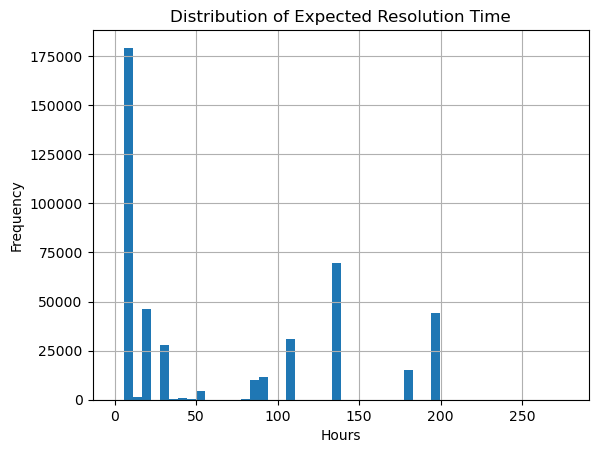

In [25]:
import matplotlib.pyplot as plt

df["expected_resolution"].hist(bins=50)
plt.title("Distribution of Expected Resolution Time")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

<Axes: xlabel='resolution_score', ylabel='resolution_factor'>

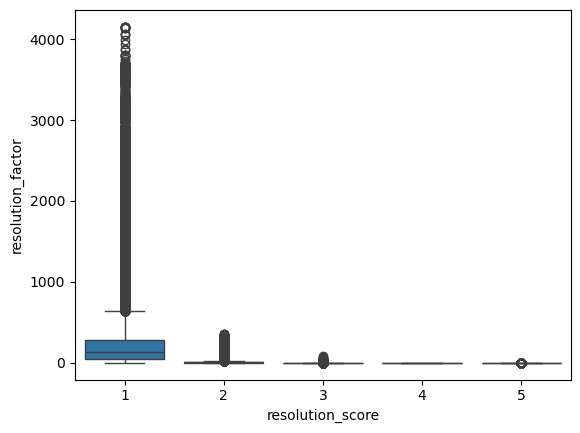

In [26]:
df["resolution_score"].value_counts(normalize=True)
df.groupby("domain")["resolution_score"].value_counts(normalize=True)

import seaborn as sns

sns.boxplot(x="resolution_score", y="resolution_factor", data=df)

In [35]:
df.shape

(442395, 32)

In [36]:
df.to_csv("../../data/geocoded_data/new_scores.csv", index=False)

In [28]:
domain_name = "Water & Sewer"

domain_df = df[df["domain"] == domain_name]

In [29]:
domain_df["expected_resolution"].describe()

count    63819.000000
mean        10.378207
std          0.944012
min          9.782083
25%          9.782083
50%         10.576389
75%         10.699444
max         17.017778
Name: expected_resolution, dtype: float64

In [30]:
domain_df["expected_resolution"].median()

np.float64(10.57638888888889)

In [31]:
sample = domain_df.sample(5)[[
    "issue_type",
    "resolution_time_hours",
    "expected_resolution",
    "resolution_factor",
    "resolution_score"
]]

sample

,issue_type,resolution_time_hours,expected_resolution,resolution_factor,resolution_score
111721,Service Failure,28.784722,17.017778,1.691450,3
436343,Billing / Account,70.916667,9.782083,7.249649,2
1094,Hazard / Emergency,9.810556,10.699444,0.916922,3
21034,Billing / Account,9.663611,9.782083,0.987889,3
248637,Hazard / Emergency,11.008889,10.699444,1.028922,3


In [32]:
df["resolution_score"].value_counts(normalize=True)

resolution_score
3    0.499825
2    0.149963
4    0.147861
5    0.102323
1    0.100028
Name: proportion, dtype: float64

In [1]:

import pandas as pd

df = pd.read_csv("../../data/geocoded_data/new_scores.csv")

# View first few rows
print(df.head())

C:\Users\shrey\AppData\Local\Temp\ipykernel_13484\1351881640.py:3: DtypeWarning: Columns (3,4,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data/geocoded_data/new_scores.csv")


                Opened                                        Description  \
0  2021-03-02 13:30:00  Information on How to Request an Account Adjus...   
1  2021-03-03 13:30:00  Information on How to Dispute Your Water and S...   
2  2021-03-03 13:30:00  Information on How to Dispute Your Water and S...   
3  2021-03-09 13:30:00  Street Light Bulb Replacement or Street Light ...   
4  2021-03-11 13:30:00  Right of Way Maintenance Visibility/Overgrowth...   

                                Address Zip Code        Closed Date 1  \
0     4501 Dudley LN NW, Atlanta, 30327    30327  2021-09-13 11:28:56   
1     238 peachtree cir, ATLANTA, 30309    30309  2021-07-15 12:54:21   
2  3434 Habersham Rd NW, Atlanta, 30305    30305  2022-05-26 09:54:34   
3   1160 Veltrie Circle, ATLANTA, 30311    30311  2021-04-14 15:24:37   
4     2855 elliott cir , ATLANTA, 30305    30305                  NaN   

         Closed Date 2    Status     Number               closed  \
0                  NaN  Resolv

In [2]:
len(df)

442395